# 03 - Linear Regression

Baseline em Spark MLlib com split temporal, encoding de categoricas e persistencia de metricas.

In [1]:
import sys
sys.path.insert(0, '/home/jovyan/work/notebooks')

import time

import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.feature import OneHotEncoder, StandardScaler, StringIndexer, VectorAssembler
from pyspark.ml.regression import LinearRegression

from _lib import (
    build_spark, append_metric,
    SEED, SPLIT_DATE, SILVER_PATH, TARGET_COL,
    NUMERIC_COLS, CATEGORICAL_COLS,
)

MODEL_OUTPUT = '/models/linear_regression'
RESIDUAL_PLOT = '/results/residual_analysis_linear_regression.png'

spark = build_spark('nyc-rideshare-linear-regression')
sns.set_theme(style='whitegrid')

In [2]:
silver_df = spark.read.parquet(SILVER_PATH)
silver_df.createOrReplaceTempView('trips_silver')

# Split temporal via Spark SQL puro (regra do projeto: data prep em SQL, ML pipeline em Python).
train_df = spark.sql(f"""
    SELECT * FROM trips_silver
    WHERE date < '{SPLIT_DATE}'
""").cache()
test_df = spark.sql(f"""
    SELECT * FROM trips_silver
    WHERE date >= '{SPLIT_DATE}'
""").cache()

train_rows = train_df.count()
test_rows = test_df.count()
if train_rows == 0 or test_rows == 0:
    raise ValueError('O split temporal exige dados antes e depois de 2023-06-01. Um unico mes como 2023-08 nao basta para treinar e avaliar.')

train_rows, test_rows

(56282410, 53834403)

In [3]:
indexers = [
    StringIndexer(inputCol=col_name, outputCol=f'{col_name}_idx', handleInvalid='keep')
    for col_name in CATEGORICAL_COLS
]
encoders = [
    OneHotEncoder(inputCol=f'{col_name}_idx', outputCol=f'{col_name}_ohe')
    for col_name in CATEGORICAL_COLS
]
numeric_assembler = VectorAssembler(inputCols=NUMERIC_COLS, outputCol='numeric_features')
scaler = StandardScaler(inputCol='numeric_features', outputCol='scaled_numeric_features', withMean=False, withStd=True)
feature_assembler = VectorAssembler(
    inputCols=['scaled_numeric_features'] + [f'{col_name}_ohe' for col_name in CATEGORICAL_COLS],
    outputCol='features'
)
lr = LinearRegression(
    labelCol=TARGET_COL,
    featuresCol='features',
    predictionCol='prediction',
    regParam=0.0,
    elasticNetParam=0.0
)

pipeline = Pipeline(stages=indexers + encoders + [numeric_assembler, scaler, feature_assembler, lr])

In [4]:
start_time = time.perf_counter()
lr_model = pipeline.fit(train_df)
train_seconds = time.perf_counter() - start_time

lr_model.write().overwrite().save(MODEL_OUTPUT)
print(f'Modelo salvo em {MODEL_OUTPUT} | treino: {train_seconds:.2f}s')

Modelo salvo em /models/linear_regression | treino: 241.50s


In [5]:
predictions = lr_model.transform(test_df).cache()
evaluators = {
    'rmse': RegressionEvaluator(labelCol=TARGET_COL, predictionCol='prediction', metricName='rmse'),
    'mae': RegressionEvaluator(labelCol=TARGET_COL, predictionCol='prediction', metricName='mae'),
    'r2': RegressionEvaluator(labelCol=TARGET_COL, predictionCol='prediction', metricName='r2')
}
metrics = {name: evaluator.evaluate(predictions) for name, evaluator in evaluators.items()}
metrics

{'rmse': 9.07359265250135, 'mae': 5.758933414798562, 'r2': 0.805620211504242}

In [6]:
predictions.createOrReplaceTempView('predictions_lr')

spark.sql("""
SELECT
    pu_borough,
    ROUND(SQRT(AVG(POWER(passenger_fare - prediction, 2))), 4) AS rmse,
    ROUND(AVG(ABS(passenger_fare - prediction)), 4) AS mae,
    COUNT(*) AS rows
FROM predictions_lr
GROUP BY 1
ORDER BY rmse DESC
""").show(truncate=False)

spark.sql("""
SELECT
    CASE
        WHEN trip_length < 2 THEN '0-2 mi'
        WHEN trip_length < 5 THEN '2-5 mi'
        WHEN trip_length < 10 THEN '5-10 mi'
        ELSE '10+ mi'
    END AS distance_bucket,
    ROUND(SQRT(AVG(POWER(passenger_fare - prediction, 2))), 4) AS rmse,
    ROUND(AVG(ABS(passenger_fare - prediction)), 4) AS mae,
    COUNT(*) AS rows
FROM predictions_lr
GROUP BY 1
ORDER BY distance_bucket
""").show(truncate=False)

+-------------+-------+-------+--------+
|pu_borough   |rmse   |mae    |rows    |
+-------------+-------+-------+--------+
|EWR          |47.4931|44.4762|3       |
|Manhattan    |10.6613|7.2453 |21135073|
|Queens       |9.2516 |5.4189 |11096402|
|Brooklyn     |7.4157 |4.7343 |14457628|
|Staten Island|6.9709 |4.1575 |782289  |
|Bronx        |6.2311 |3.9398 |6363008 |
+-------------+-------+-------+--------+



+---------------+-------+-------+--------+
|distance_bucket|rmse   |mae    |rows    |
+---------------+-------+-------+--------+
|0-2 mi         |5.4089 |3.8527 |18523719|
|10+ mi         |16.9457|11.7414|6054673 |
|2-5 mi         |7.1404 |4.8507 |19015145|
|5-10 mi        |10.744 |7.3563 |10240866|
+---------------+-------+-------+--------+



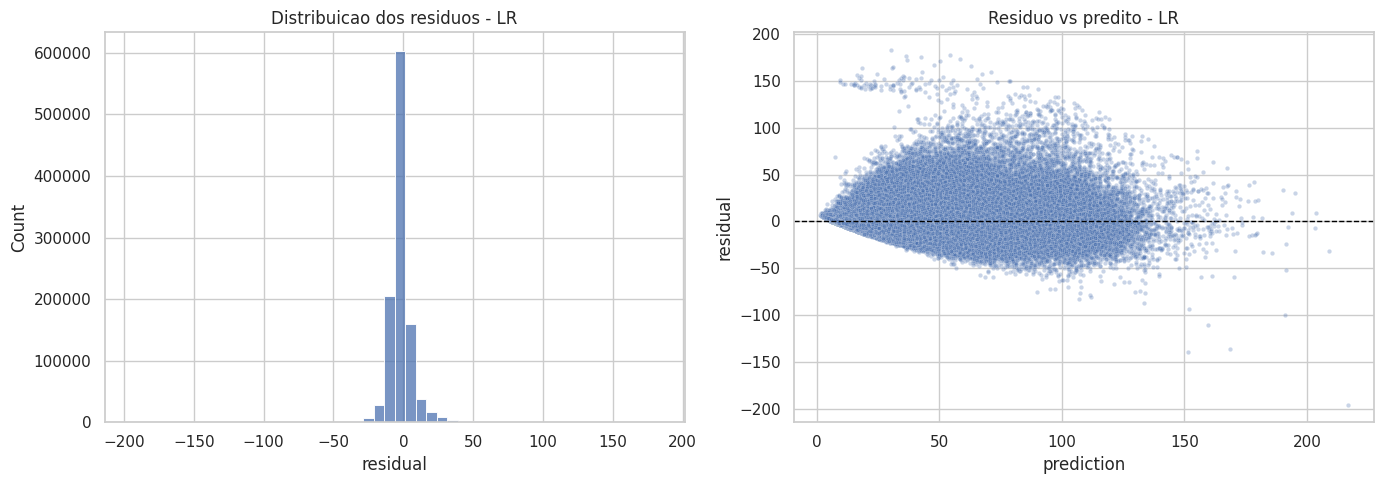

In [7]:
residual_pdf = (predictions
    .select('prediction', TARGET_COL)
    .sample(False, 0.02, SEED)
    .toPandas())
residual_pdf['residual'] = residual_pdf[TARGET_COL] - residual_pdf['prediction']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(residual_pdf['residual'], bins=50, ax=axes[0])
axes[0].set_title('Distribuicao dos residuos - LR')
sns.scatterplot(data=residual_pdf, x='prediction', y='residual', s=10, alpha=0.3, ax=axes[1])
axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('Residuo vs predito - LR')
plt.tight_layout()
plt.savefig(RESIDUAL_PLOT, dpi=150, bbox_inches='tight')
plt.show()

In [8]:
results_df = append_metric(
    model='linear_regression',
    rmse=metrics['rmse'],
    mae=metrics['mae'],
    r2=metrics['r2'],
    train_seconds=train_seconds,
    notes='baseline com StandardScaler e one-hot encoding',
)
results_df.tail(10)

/home/jovyan/work/notebooks/_lib.py:138: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([existing[columns], df], ignore_index=True)


,run_id,timestamp_utc,git_sha,model,rmse,mae,r2,train_seconds,notes
0,9fc930c0,2026-05-07T00:50:07,unknown,linear_regression,9.073593,5.758933,0.80562,241.497893,baseline com StandardScaler e one-hot encoding


In [9]:
spark.stop()